In [79]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from glob import glob

In [80]:
# Importing data
female_path = glob('../gender_data/female/*.jpg')
male_path = glob('../gender_data/male/*.jpg')

In [81]:
print('Female', len(female_path))
print('male', len(male_path))

Female 4693
male 5383


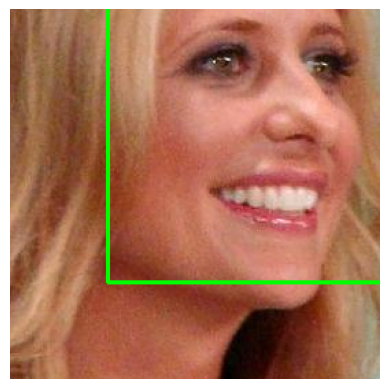

In [112]:
### Read image and convert to RGB
img = cv2.imread(female_path[567])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

### Apply Haar Cascade Classifier
haar = cv2.CascadeClassifier('../models/haarcascade_frontalface_default.xml')
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
faces = haar.detectMultiScale(gray, 1.1,7)
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x+w, y+h), (0, 255, 0), 2)

    ### Crop Faces
    faces_roi = img_rgb[x:x+w, y:y+h]
    plt.imshow(faces_roi)
    plt.axis('off')
    plt.show()

### Save Cropped_Images

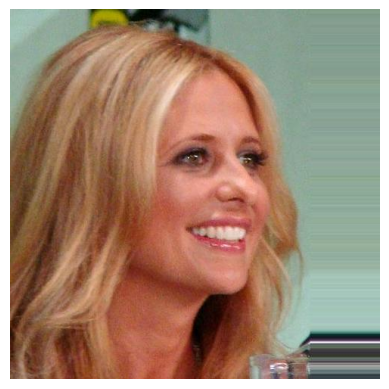

In [107]:
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## Crop All Faces

In [113]:
female_path = glob('../gender_data/female/*.jpg')
male_path = glob('../gender_data/male/*.jpg')

In [118]:
import cv2
import os

def crop_faces(filepath, gender, output_dir=f"../cropped_faces"):
    
    haar = cv2.CascadeClassifier(
        "../models/haarcascade_frontalface_default.xml"
    )

    no_faces = 0
    total_images = len(filepath)
    processed_images = 0

    gender_dir = os.path.join(output_dir, gender)
    os.makedirs(gender_dir, exist_ok=True)

    for i, image_path in enumerate(filepath):

        try:
            img = cv2.imread(image_path)

            if img is None:
                print(f"Could not read {image_path}")
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            faces = haar.detectMultiScale(
                gray,
                1.1,
                5
            )

            if len(faces) == 0:
                no_faces += 1
                print(f"Could not read face {image_path}")

                continue

            for j, (x, y, w, h) in enumerate(faces):

                face_roi = img[y:y+h, x:x+w]

                save_path = os.path.join(
                    gender_dir,
                    f"{gender}_{i}_{j}.jpg"
                )

                cv2.imwrite(save_path, face_roi)
                processed_images += 1

        except Exception as e:
            print(f"Unable to crop face {image_path}: {e}")

    return {
        "Gender": gender,
        "Total Images": total_images,
        "No Faces": no_faces,
        "Processed Images": processed_images
    }

In [119]:
crop_faces(female_path, 'females')

Could not read face ../gender_data/female\female_000021.jpg
Could not read face ../gender_data/female\female_000024.jpg
Could not read face ../gender_data/female\female_000026.jpg
Could not read face ../gender_data/female\female_000032.jpg
Could not read face ../gender_data/female\female_000039.jpg
Could not read face ../gender_data/female\female_000061.jpg
Could not read face ../gender_data/female\female_000066.jpg
Could not read face ../gender_data/female\female_000072.jpg
Could not read face ../gender_data/female\female_000074.jpg
Could not read face ../gender_data/female\female_000080.jpg
Could not read face ../gender_data/female\female_000085.jpg
Could not read face ../gender_data/female\female_000114.jpg
Could not read face ../gender_data/female\female_000118.jpg
Could not read face ../gender_data/female\female_000119.jpg
Could not read face ../gender_data/female\female_000122.jpg
Could not read face ../gender_data/female\female_000126.jpg
Could not read face ../gender_data/femal

{'Gender': 'females',
 'Total Images': 4693,
 'No Faces': 945,
 'Processed Images': 3943}

In [120]:
crop_faces(male_path, 'males')

Could not read face ../gender_data/male\male_000005.jpg
Could not read face ../gender_data/male\male_000007.jpg
Could not read face ../gender_data/male\male_000009.jpg
Could not read face ../gender_data/male\male_000011.jpg
Could not read face ../gender_data/male\male_000013.jpg
Could not read face ../gender_data/male\male_000014.jpg
Could not read face ../gender_data/male\male_000019.jpg
Could not read face ../gender_data/male\male_000020.jpg
Could not read face ../gender_data/male\male_000026.jpg
Could not read face ../gender_data/male\male_000034.jpg
Could not read face ../gender_data/male\male_000036.jpg
Could not read face ../gender_data/male\male_000039.jpg
Could not read face ../gender_data/male\male_000040.jpg
Could not read face ../gender_data/male\male_000042.jpg
Could not read face ../gender_data/male\male_000044.jpg
Could not read face ../gender_data/male\male_000047.jpg
Could not read face ../gender_data/male\male_000052.jpg
Could not read face ../gender_data/male\male_000

{'Gender': 'males',
 'Total Images': 5383,
 'No Faces': 1797,
 'Processed Images': 3720}

In [123]:
# Importing data
female_path = glob('../gender_data/female/*.jpg')
male_path = glob('../gender_data/male/*.jpg')
print('Original Files', len(female_path))
print('Original Files', len(male_path))
female_path_cropped = glob('../cropped_faces/females/*.jpg')
male_path_cropped = glob('../cropped_faces/males/*.jpg')
print('Cropped Files', len(female_path_cropped))
print('Cropped Files', len(male_path_cropped))
print("Total Cropped Faces: ", (len(female_path_cropped) + len(male_path_cropped)))

cropped_faces = len(female_path_cropped) + len(male_path_cropped)
original_images = len(female_path) + len(male_path)
print("Detection Rate: ", (cropped_faces / original_images) * 100)

Original Files 4693
Original Files 5383
Cropped Files 3943
Cropped Files 3720
Total Cropped Faces:  7663
Detection Rate:  76.05200476379515
